In [2]:
import pandas as pd

DATA_PATH = "../Data"
orders = pd.read_csv(f"{DATA_PATH}/orders.csv")
order_items = pd.read_csv(f"{DATA_PATH}/order_items.csv")
products = pd.read_csv(f"{DATA_PATH}/products.csv")
customers = pd.read_csv(f"{DATA_PATH}/customers.csv")
sellers = pd.read_csv(f"{DATA_PATH}/sellers.csv")
order_payments = pd.read_csv(f"{DATA_PATH}/order_payments.csv")

# Merge into one dataframe
df = orders.merge(order_items, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(customers, on="customer_id", how="left")
df = df.merge(sellers, on="seller_id", how="left")
df = df.merge(order_payments, on="order_id", how="left")
print(df.shape)
df.head()

(118434, 33)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,3149,sao paulo,SP,9350.0,maua,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,3149,sao paulo,SP,9350.0,maua,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,3149,sao paulo,SP,9350.0,maua,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,47813,barreiras,BA,31570.0,belo horizonte,SP,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,75265,vianopolis,GO,14840.0,guariba,SP,1.0,credit_card,3.0,179.12


In [3]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df = df[df['order_status'] == 'delivered'].copy()
df = df.dropna(subset=['order_delivered_customer_date'])
df['is_late'] = (df['order_delivered_customer_date'] > df['order_estimated_delivery_date']).astype(int)
print(df['is_late'].value_counts(normalize=True))

is_late
0    0.921534
1    0.078466
Name: proportion, dtype: float64


In [4]:
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_dayofweek'] = df['order_purchase_timestamp'].dt.dayofweek
df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour

df['estimated_delivery_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days

df['different_state'] = (df['customer_state'] != df['seller_state']).astype(int)

features = [
    'price', 'freight_value', 'product_weight_g',
    'product_length_cm', 'product_height_cm', 'product_width_cm',
    'payment_installments', 'payment_type',
    'purchase_month', 'purchase_dayofweek', 'purchase_hour',
    'estimated_delivery_days', 'different_state',
    'customer_state', 'seller_state'
]
model_df = df[features + ['is_late']].dropna()
print(model_df.shape)

(115027, 16)


In [5]:
categorical_cols = ['payment_type', 'customer_state', 'seller_state']
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

In [6]:
from sklearn.model_selection import train_test_split

X = model_df.drop('is_late', axis=1)
y = model_df['is_late']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

baseline = LogisticRegression(max_iter=1000, class_weight='balanced')
baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)
y_proba = baseline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred))
print("LogReg ROC-AUC:", roc_auc_score(y_test, y_proba))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.95      0.65      0.77     21201
           1       0.13      0.62      0.22      1805

    accuracy                           0.65     23006
   macro avg       0.54      0.63      0.49     23006
weighted avg       0.89      0.65      0.73     23006

LogReg ROC-AUC: 0.6799516329718938


C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost Results ===")
print(classification_report(y_test, y_pred_xgb))
print("XGB ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

=== XGBoost Results ===
              precision    recall  f1-score   support

           0       0.96      0.77      0.86     21201
           1       0.20      0.67      0.31      1805

    accuracy                           0.77     23006
   macro avg       0.58      0.72      0.58     23006
weighted avg       0.90      0.77      0.82     23006

XGB ROC-AUC: 0.7944369032924673


In [9]:
print("Predictions identical?", (y_pred == y_pred_xgb).all())
print("Probabilities identical?", (y_proba == y_proba_xgb).all())

print("\n=== Logistic Regression ===")
print(classification_report(y_test, y_pred))
print("LogReg ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("XGB ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

Predictions identical? False
Probabilities identical? False

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.95      0.65      0.77     21201
           1       0.13      0.62      0.22      1805

    accuracy                           0.65     23006
   macro avg       0.54      0.63      0.49     23006
weighted avg       0.89      0.65      0.73     23006

LogReg ROC-AUC: 0.6799516329718938

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.96      0.77      0.86     21201
           1       0.20      0.67      0.31      1805

    accuracy                           0.77     23006
   macro avg       0.58      0.72      0.58     23006
weighted avg       0.90      0.77      0.82     23006

XGB ROC-AUC: 0.7944369032924673


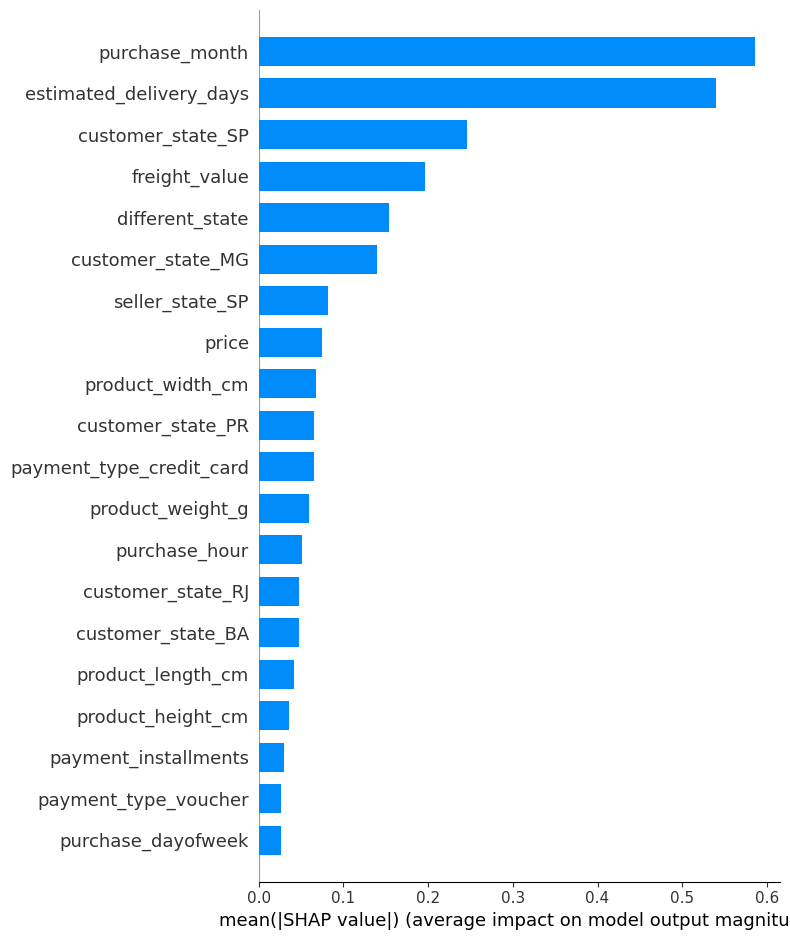

In [10]:
import shap
# Create the explainer based on the XGBoost model
explainer = shap.TreeExplainer(xgb)

# Calculate SHAP values on a sample of the test set (not the whole thing, to save time)
X_sample = X_test.sample(n=2000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Plot the most influential features
shap.summary_plot(shap_values, X_sample, plot_type="bar")

In [11]:
import joblib

joblib.dump(xgb, r"C:\Users\USER\Desktop\Olist\Model\xgb_model.joblib")
joblib.dump(X_train.columns.tolist(), r"C:\Users\USER\Desktop\Olist\Model\model_columns.joblib")

print("Model and columns saved!")

Model and columns saved!
